In [1]:
!pip install ollama

In [2]:
import ollama

response = ollama.chat(
    model="mistral",
    messages=[{"role": "user", "content": "Hello"}]
)

print(response['message']['content'])

 Hello there! How can I assist you today? Is there something specific you'd like to know or discuss? I'm here to help with a wide range of topics, from answering questions and providing explanations, to engaging in interesting conversations. What would you like to talk about?


✅ PDF Loaded Successfully!
📄 File: D:\LENOVO\Download\ARCS Data sample.pdf
📊 Total Pages: 407

👀 Preview Page 0


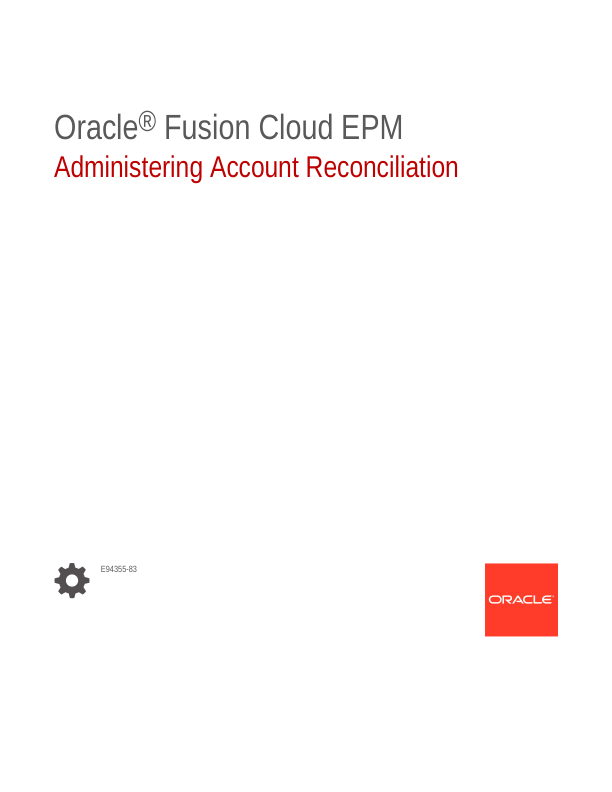


👀 Preview Page 1


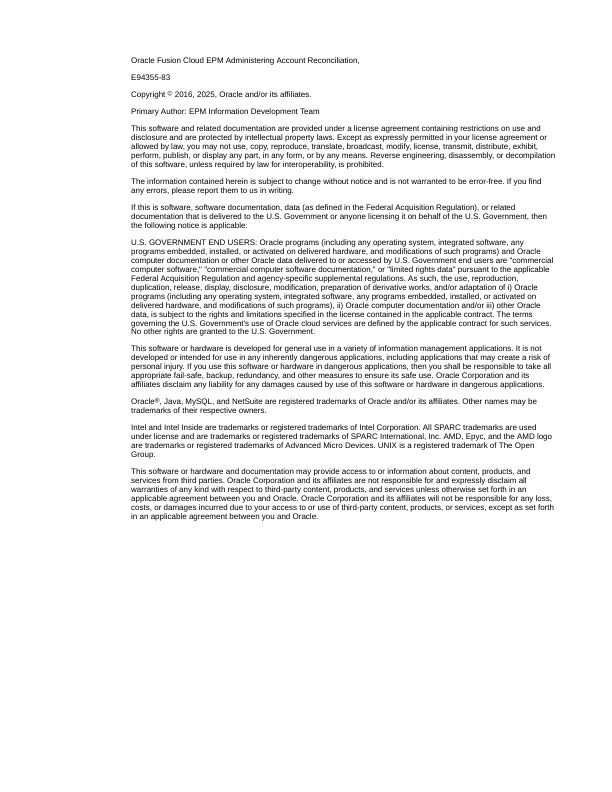


🖼️ Total Extracted Images: 255


In [3]:
import fitz
import os
from IPython.display import display, Image as IPImage

file_path = r"D:\LENOVO\Download\ARCS Data sample.pdf"

doc = fitz.open(file_path)

print("✅ PDF Loaded Successfully!")
print("📄 File:", file_path)
print("📊 Total Pages:", len(doc))

texts = []
image_paths = []

img_folder = "D:\LENOVO\Download\Images1"
os.makedirs(img_folder, exist_ok=True)

# 🔹 Extract + Preview
for page_num in range(len(doc)):
    page = doc[page_num]
    
    # Extract text
    texts.append(page.get_text())
    
    # Show first 2 pages preview
    if page_num < 2:
        pix = page.get_pixmap()
        preview_path = f"preview_{page_num}.png"
        pix.save(preview_path)
        
        print(f"\n👀 Preview Page {page_num}")
        display(IPImage(filename=preview_path))
    
    # Extract images
    for i, img in enumerate(page.get_images(full=True)):
        xref = img[0]
        base = doc.extract_image(xref)
        
        path = f"{img_folder}/p{page_num}_{i}.png"
        
        with open(path, "wb") as f:
            f.write(base["image"])
        
        image_paths.append((page_num, path))

print("\n🖼️ Total Extracted Images:", len(image_paths))

In [4]:
chunks = []
chunk_page_map = []

for i, text in enumerate(texts):
    for chunk in text.split("\n\n"):
        if len(chunk) > 100:
            chunks.append(chunk)
            chunk_page_map.append(i)

# ✅ Chunk count
print("🧩 Total Chunks:", len(chunks))

🧩 Total Chunks: 406


In [5]:
from collections import Counter

page_counts = Counter(chunk_page_map)
print("📊 Chunks per page (sample):", dict(list(page_counts.items())[:5]))

📊 Chunks per page (sample): {1: 1, 2: 1, 3: 1, 4: 1, 5: 1}


In [6]:
print("\n🔍 Sample Chunks:\n")
for i in range(3):
    print(f"Chunk {i}:\n", chunks[i][:200], "\n")


🔍 Sample Chunks:

Chunk 0:
 Oracle Fusion Cloud EPM Administering Account Reconciliation,
E94355-83
Copyright © 2016, 2025, Oracle and/or its affiliates.
Primary Author: EPM Information Development Team
This software and related 

Chunk 1:
 Contents
 
Documentation Accessibility
 
Documentation Feedback
1   
Creating and Running an EPM Center of Excellence
2   
Learning About Account Reconciliation
Overview of Reconciliation Compliance
1 

Chunk 2:
 Application
18
Reconciliation Activity
20
Overview of Reconciliation Compliance Configuration
21
Periods
24
Services
25
Tools
26
Appearance
27
Announcements
27
Service Activity Report
27
Audit Report
 



In [7]:
avg_len = sum(len(c) for c in chunks) / len(chunks)
print("📏 Avg Chunk Length:", int(avg_len))

📏 Avg Chunk Length: 1847


In [8]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [9]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import numpy as np

text_model = SentenceTransformer('all-mpnet-base-v2')
clip_model = SentenceTransformer('clip-ViT-B-32')

# Text embeddings
text_embeddings = text_model.encode(chunks)

# Image embeddings
image_embeddings = []
image_files = []

for page, path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        emb = clip_model.encode(img)
        image_embeddings.append(emb)
        image_files.append(path)
    except:
        continue

image_embeddings = np.array(image_embeddings)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: C:\Users\LENOVO\.cache\huggingface\hub\models--sentence-transformers--clip-ViT-B-32\snapshots\327ab6726d33c0e22f920c83f2ff9e4bd38ca37f\0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
import faiss

text_index = faiss.IndexFlatL2(len(text_embeddings[0]))
text_index.add(np.array(text_embeddings))

image_index = faiss.IndexFlatL2(len(image_embeddings[0]))
image_index.add(image_embeddings)

In [14]:
print(type(image_files[0]))
print(image_files[0])

<class 'str'>
D:\LENOVO\Download\Images1/p17_0.png


In [15]:
# Build a dictionary: page number → list of image paths
page_to_images = {}

for path in image_files:
    # Extract page number from filename like "p22_0.png"
    filename = os.path.basename(path)
    try:
        page_num = int(filename.split("_")[0].replace("p", ""))
        if page_num not in page_to_images:
            page_to_images[page_num] = []
        page_to_images[page_num].append(path)
    except:
        continue

print(f"✅ Page-to-image mapping built: {len(page_to_images)} pages have images")
for page, imgs in sorted(page_to_images.items())[:5]:
    print(f"  Page {page}: {len(imgs)} images")

✅ Page-to-image mapping built: 187 pages have images
  Page 17: 1 images
  Page 18: 1 images
  Page 21: 1 images
  Page 24: 2 images
  Page 27: 2 images


In [16]:
text_embeddings_norm = text_model.encode(chunks, normalize_embeddings=True)
text_index = faiss.IndexFlatIP(text_embeddings_norm.shape[1])
text_index.add(np.array(text_embeddings_norm))
print(f"✅ Text index rebuilt: {text_index.ntotal} vectors (normalized)")

✅ Text index rebuilt: 406 vectors (normalized)


In [18]:
from IPython.display import display, Image as IPImage
import numpy as np
import os
import ollama

def extract_best_sentences(chunks_list, query, top_n=5):
    all_sentences = []
    for chunk in chunks_list:
        sentences = [s.strip() for s in chunk.replace("\n", " ").split(".") if len(s.strip()) > 20]
        all_sentences.extend(sentences)
    if not all_sentences:
        return "\n".join(chunks_list)
    query_emb = text_model.encode([query], normalize_embeddings=True)
    sent_embs = text_model.encode(all_sentences, normalize_embeddings=True)
    scores = np.dot(sent_embs, query_emb.T).flatten()
    top_indices = np.argsort(scores)[::-1][:top_n]
    best = [all_sentences[i] + "." for i in sorted(top_indices)]
    return "\n".join(best)

def chatbot():
    print("🤖 Multimodal RAG Chatbot (Mistral)\n")

    while True:
        query = input("🧑 Ask: ")

        if query.lower() == "exit":
            break

        # 🔹 TEXT SEARCH
        q_emb = text_model.encode([query], normalize_embeddings=True)
        D, I = text_index.search(np.array(q_emb), k=10)

        best_score = float(D[0][0])
        print(f"[DEBUG] Best text score: {best_score:.3f}")

        # 🔹 OUT-OF-PDF CHECK
        if best_score < 0.35:
            print("\n❌ This question is not related to the document.")
            print("Please ask something related to the PDF content.\n")
            print("=" * 60)
            continue

        # 🔹 GET RELEVANT CHUNKS + PAGES
        retrieved_chunks = []
        retrieved_pages = set()

        for j in range(len(I[0])):
            if float(D[0][j]) > 0.25:
                retrieved_chunks.append(chunks[I[0][j]])
                retrieved_pages.add(chunk_page_map[I[0][j]])

        if not retrieved_chunks:
            print("\n❌ No relevant content found in the document.\n")
            print("=" * 60)
            continue

        # 🔹 BUILD CONTEXT FROM CHUNKS
        context = "\n\n".join(retrieved_chunks)

        # 🔹 GENERATE ANSWER USING MISTRAL
        print("\n📄 Answer:\n")

        response = ollama.chat(
            model="mistral",
            messages=[
                {
                    "role": "system",
                    "content": """You are a PDF document assistant. Follow these rules strictly:
1. Answer ONLY from the context provided below.
2. If the answer is NOT in the context, say exactly: "Not available in document."
3. Never use your own knowledge. Never guess.
4. Give DETAILED and COMPLETE answers with all steps and details from the context.
5. Format the answer clearly with proper structure."""
                },
                {
                    "role": "user",
                    "content": f"""Context:
{context}

Question: {query}

Instructions: Answer using ONLY the context above. If not found, say "Not available in document." Do not use your own knowledge."""
                }
            ]
        )

        answer = response['message']['content']
        print(answer)

        # 🔹 IMAGE RETRIEVAL — based on matching PAGES
        print(f"\n[DEBUG] Retrieved pages: {sorted(retrieved_pages)}")
        print("\n🖼️ Relevant Images:\n")
        shown = 0

        for page in sorted(retrieved_pages):
            if page in page_to_images:
                for path in page_to_images[page]:
                    if os.path.exists(path):
                        print(f"  [Page {page}] {os.path.basename(path)}")
                        display(IPImage(filename=path))
                        shown += 1
                        if shown >= 5:
                            break
            if shown >= 5:
                break

        if shown == 0:
            print("  No images found on the relevant pages.")

        print("\n" + "=" * 60)



🤖 Multimodal RAG Chatbot (Mistral)



🧑 Ask:  what is the capital of india?


[DEBUG] Best text score: 0.098

❌ This question is not related to the document.
Please ask something related to the PDF content.



🧑 Ask:  Example: Creating a Chart to Display Unmatched Transactions by Account Type?


[DEBUG] Best text score: 0.753

📄 Answer:

 To create a chart that displays unmatched transactions by account type, follow these steps as described in the provided document:

1. Navigate to the dashboard where you want to add this chart view.

2. In one of the quadrants (top-left, top-right, bottom-right, or bottom-left), click Settings to open the View Settings dialog box.

3. Click on Create a new chart view and give it an appropriate title like "Unmatched Transactions by Account Type".

4. In the Properties tab:
   - Set the Type as Combination.
   - Choose Bar Label Position as Center.
   - Select Missing Values as Zero.

5. In the Layout tab:
   - In the X Axis section, set the Type as Attribute and select Account Type in Attribute 1.
   - In the Legend (Series) section, click Add to create a row with the following properties:
     - Value: Unmatched Transactions (Count). In Aggregation, select Sum.
     - Categories: Account Type.

6. In the Legend tab, customize the label for th

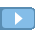

  [Page 270] p270_0.png


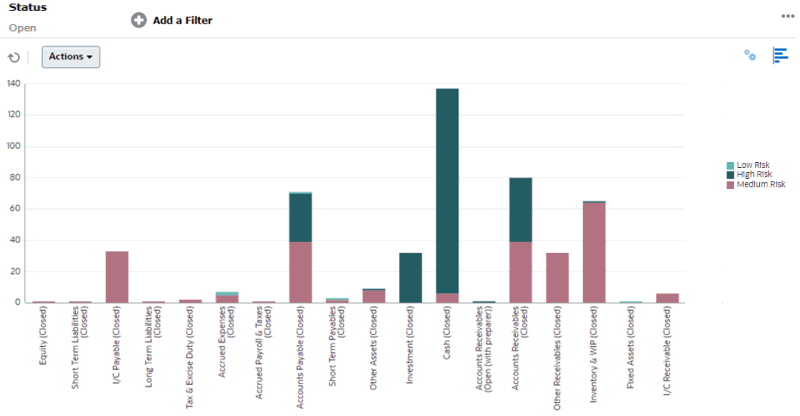

  [Page 271] p271_0.png


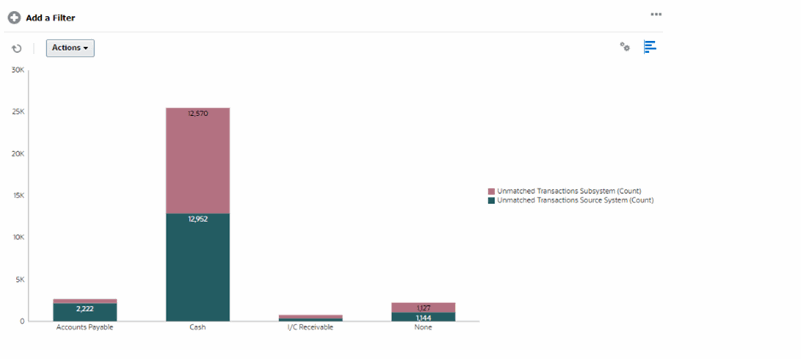

  [Page 292] p292_0.png


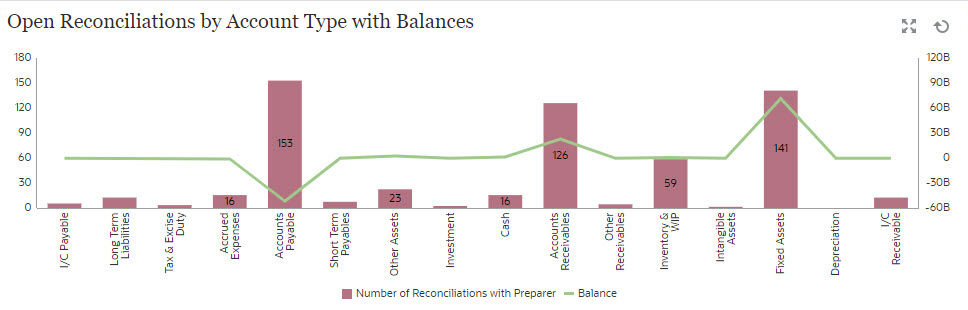

  [Page 298] p298_0.png


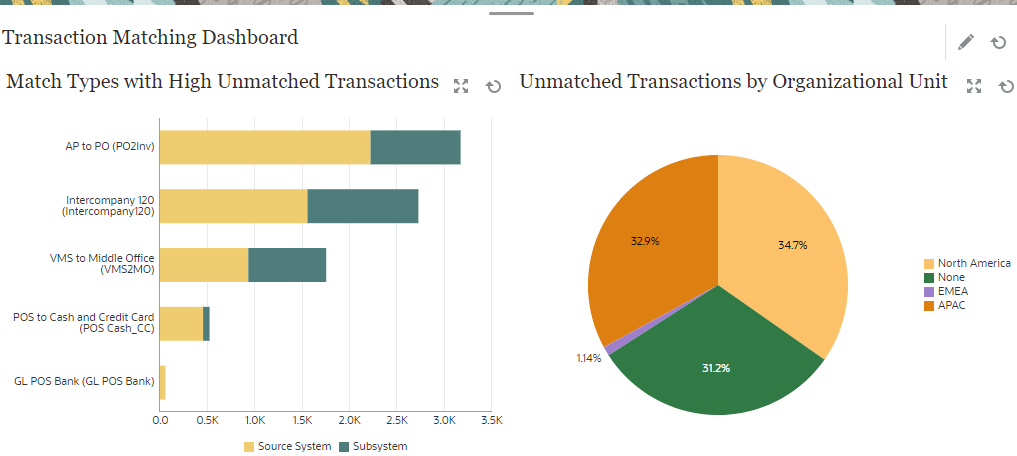

🧑 Ask:  exit


In [19]:
chatbot()

In [ ]:
# START TIME = 11.31 AM 
#END TIME =